# model_usage

Load any trained model, score, evaluate and visualise results on the three-way split (70 / 15 / 15).

Works with both model types - `score_windows()` dispatches automatically:
- **sklearn PCA**  → `models/pca.pkl`
- **Keras AE**     → `models/lstm_ae.keras` / `models/cnn_ae.keras`


## 0 - Setup & Imports

In [15]:
import sys, json, pickle, time
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

from sentinel.ml_logic.data       import PROCESSED_DIR, MODELS_DIR
from sentinel.ml_logic.scorer    import score_windows
from sentinel.ml_logic.thresholds import tune_threshold
from sentinel.ml_logic.metrics    import event_f05, compute_all_metrics
from sentinel.ml_logic.validation import bootstrap_f05_ci
from sentinel.ml_logic.data       import find_anomaly_segments
from sentinel.params import ANOMALY_COLOR, NOMINAL_COLOR, WINDOW_SIZE

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
print('Ready')

Ready


---
## 1 - Load Data


In [16]:
with open(PROCESSED_DIR / 'preprocessing_config.json') as f:
    cfg = json.load(f)
WIN    = cfg['window_size']
N_FEAT = cfg['n_features']

t0 = time.time()
val_scaled         = np.load(PROCESSED_DIR / 'val_scaled.npy')
y_val              = np.load(PROCESSED_DIR / 'y_val.npy')
test_intern_scaled = np.load(PROCESSED_DIR / 'test_intern_scaled.npy')
y_test_intern      = np.load(PROCESSED_DIR / 'y_test_intern.npy')
print(f'loaded in {time.time()-t0:.1f}s')
print(f'  val         : {val_scaled.shape}  | anom rows: {int(y_val.sum()):,}')
print(f'  test_intern : {test_intern_scaled.shape}  | anom rows: {int(y_test_intern.sum()):,}')

loaded in 0.4s
  val         : (2232277, 58)  | anom rows: 246,463
  test_intern : (2186220, 58)  | anom rows: 214,961


---
## 2 - Load Model

Run **one** cell below.


In [17]:
# Option A: sklearn PCA
""" with open(MODELS_DIR / 'pca.pkl', 'rb') as f:
    model = pickle.load(f)
MODEL_NAME = 'PCA'
print(f'PCA loaded - {model.n_components_} components') """

" with open(MODELS_DIR / 'pca.pkl', 'rb') as f:\n    model = pickle.load(f)\nMODEL_NAME = 'PCA'\nprint(f'PCA loaded - {model.n_components_} components') "

In [18]:
# Option B: Keras autoencoder
import tensorflow as tf
model = tf.keras.models.load_model(MODELS_DIR / 'lstm_ae.keras'); MODEL_NAME = 'LSTM-AE'
#model = tf.keras.models.load_model(MODELS_DIR / 'cnn_ae.keras');  MODEL_NAME = 'CNN-AE'

---
## 3 - Scoring window


In [19]:
t0 = time.time()
scores_val         = score_windows(model, val_scaled,         win=WIN)
scores_test_intern = score_windows(model, test_intern_scaled, win=WIN)
print(f'scored in {time.time()-t0:.1f}s')
print(f'  val  - nominal mean: {scores_val[y_val==0].mean():.5f}  '
      f'anomaly mean: {scores_val[y_val==1].mean():.5f}')
print(f'  test - nominal mean: {scores_test_intern[y_test_intern==0].mean():.5f}  '
      f'anomaly mean: {scores_test_intern[y_test_intern==1].mean():.5f}')

scored in 39.6s
  val  - nominal mean: 0.15202  anomaly mean: 0.56209
  test - nominal mean: 0.76593  anomaly mean: 2.44236


---
## 4 - Tune Threshold on Val


In [20]:
sweep    = tune_threshold(scores_val, y_val, metric_fn=event_f05)
THRESHOLD = sweep['threshold']
print(f'best threshold : {THRESHOLD:.6f}  →  val event F0.5 = {sweep["score"]:.4f}')

best threshold : 0.187300  →  val event F0.5 = 0.8333


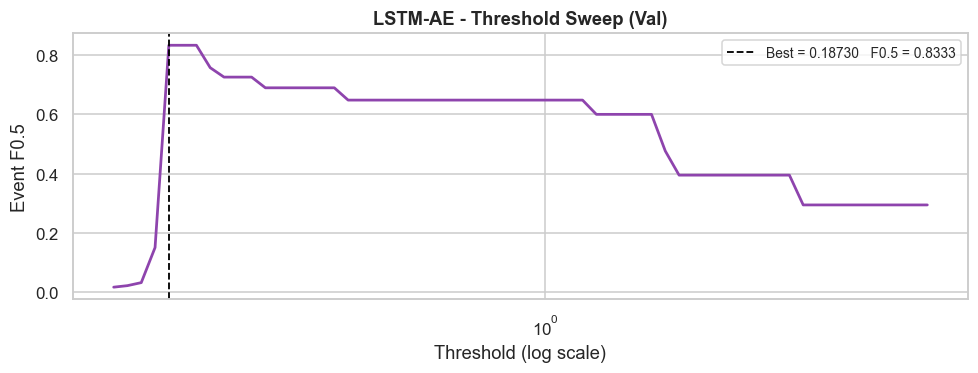

In [21]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(sweep['sweep_thresholds'], sweep['sweep_scores'], color='#8e44ad', lw=1.8)
ax.axvline(THRESHOLD, color='black', ls='--', lw=1.2,
           label=f'Best = {THRESHOLD:.5f}   F0.5 = {sweep["score"]:.4f}')
ax.set_xscale('log')
ax.set_xlabel('Threshold (log scale)')
ax.set_ylabel('Event F0.5')
ax.set_title(f'{MODEL_NAME} - Threshold Sweep (Val)', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

---
## 6 - Metrics


In [22]:
def print_metrics(scores, y_true, threshold, label):
    y_pred = (scores > threshold).astype(np.int8)
    m = compute_all_metrics(y_true, y_pred)
    print(f'=== {label} ===')
    for k, v in m.items():
        print(f'  {k:<26} {v}')
    return m

m_val  = print_metrics(scores_val,         y_val,         THRESHOLD, f'{MODEL_NAME} - Val')
print()
m_test = print_metrics(scores_test_intern, y_test_intern, THRESHOLD, f'{MODEL_NAME} - Test intern')

=== LSTM-AE - Val ===
  event_f05                  0.833333
  event_f1                   0.666667
  event_f2                   0.555556
  event_precision            1.0
  event_recall               0.5
  esa_f05                    0.833225
  esa_precision              0.999805
  esa_recall                 0.5
  esa_tnr                    0.999805
  event_detection_rate       0.5
  tp_events                  13
  n_events                   26
  fp_pred_events             0
  pa_f1                      0.929757
  pa_precision               0.998199
  pa_recall                  0.870098
  row_precision              0.992166
  row_recall                 0.198866
  row_f1                     0.331322

=== LSTM-AE - Test intern ===
  event_f05                  0.786164
  event_f1                   0.833333
  event_f2                   0.886525
  event_precision            0.757576
  event_recall               0.925926
  esa_f05                    0.367506
  esa_precision              0.31935

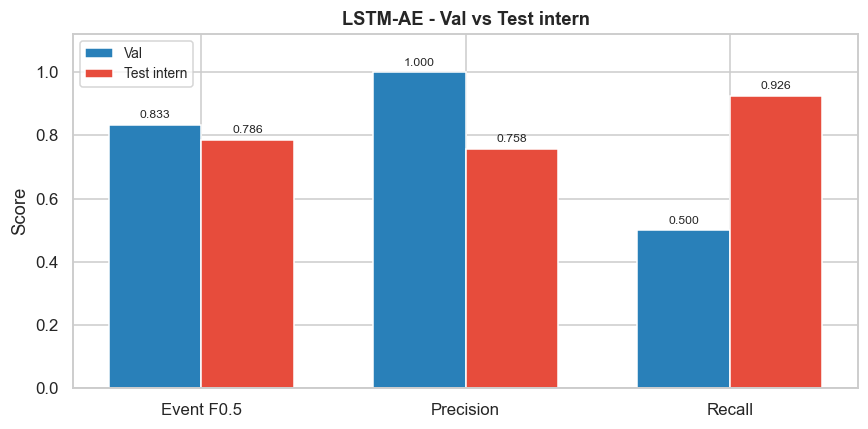

In [23]:
# Side-by-side bar chart for key metrics
keys   = ['event_f05', 'event_precision', 'event_recall']
labels = ['Event F0.5', 'Precision', 'Recall']
x      = np.arange(len(keys))
w      = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
b1 = ax.bar(x - w/2, [m_val[k]  for k in keys], w, label='Val',         color=NOMINAL_COLOR, edgecolor='white')
b2 = ax.bar(x + w/2, [m_test[k] for k in keys], w, label='Test intern', color=ANOMALY_COLOR, edgecolor='white')
ax.bar_label(b1, fmt='%.3f', fontsize=8, padding=3)
ax.bar_label(b2, fmt='%.3f', fontsize=8, padding=3)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title(f'{MODEL_NAME} - Val vs Test intern', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

---
## 7 - Validation Timeline

Where does the model flag anomalies in the val and test_intern timelines?


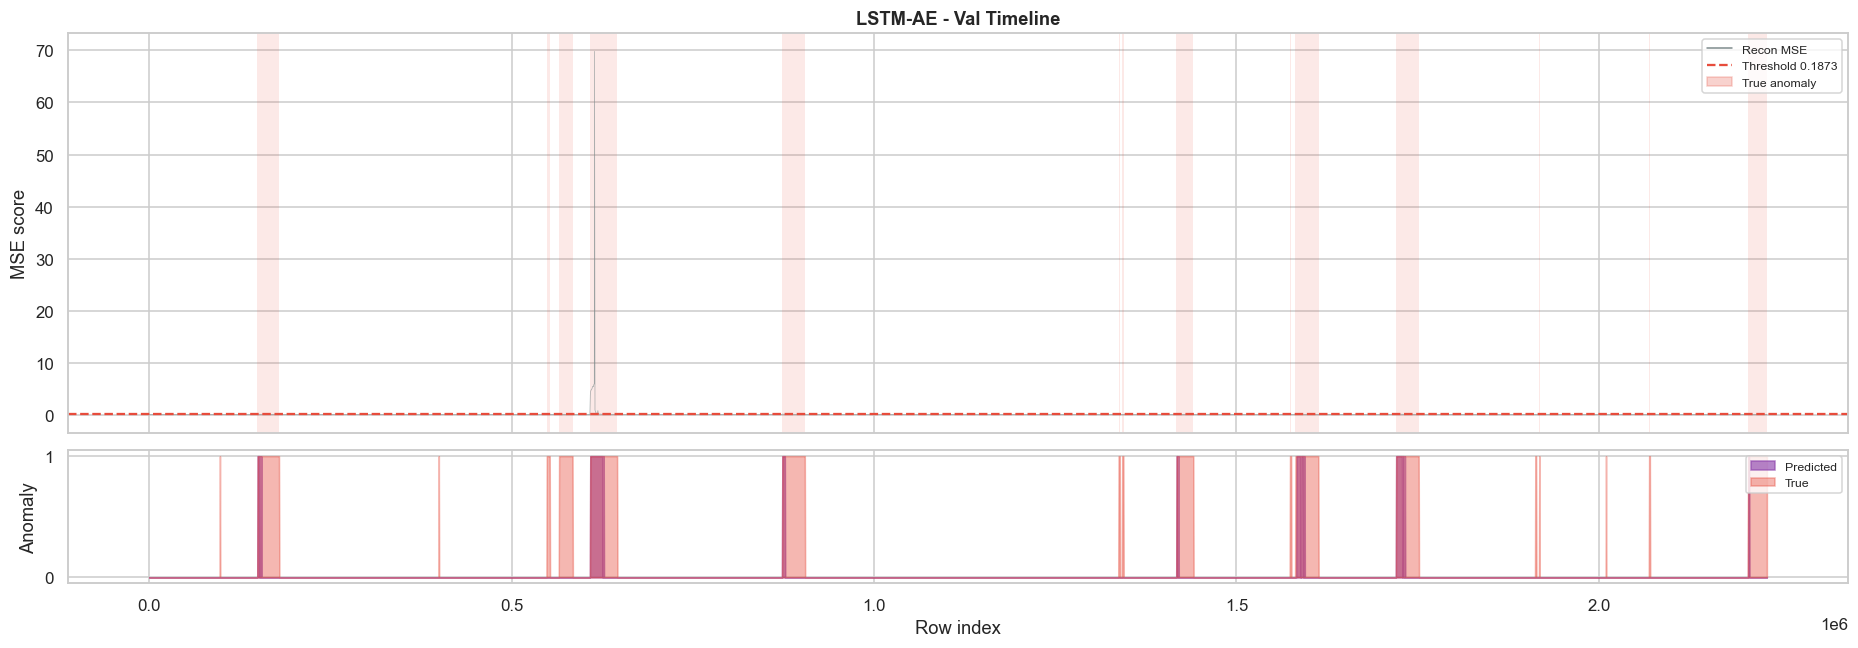

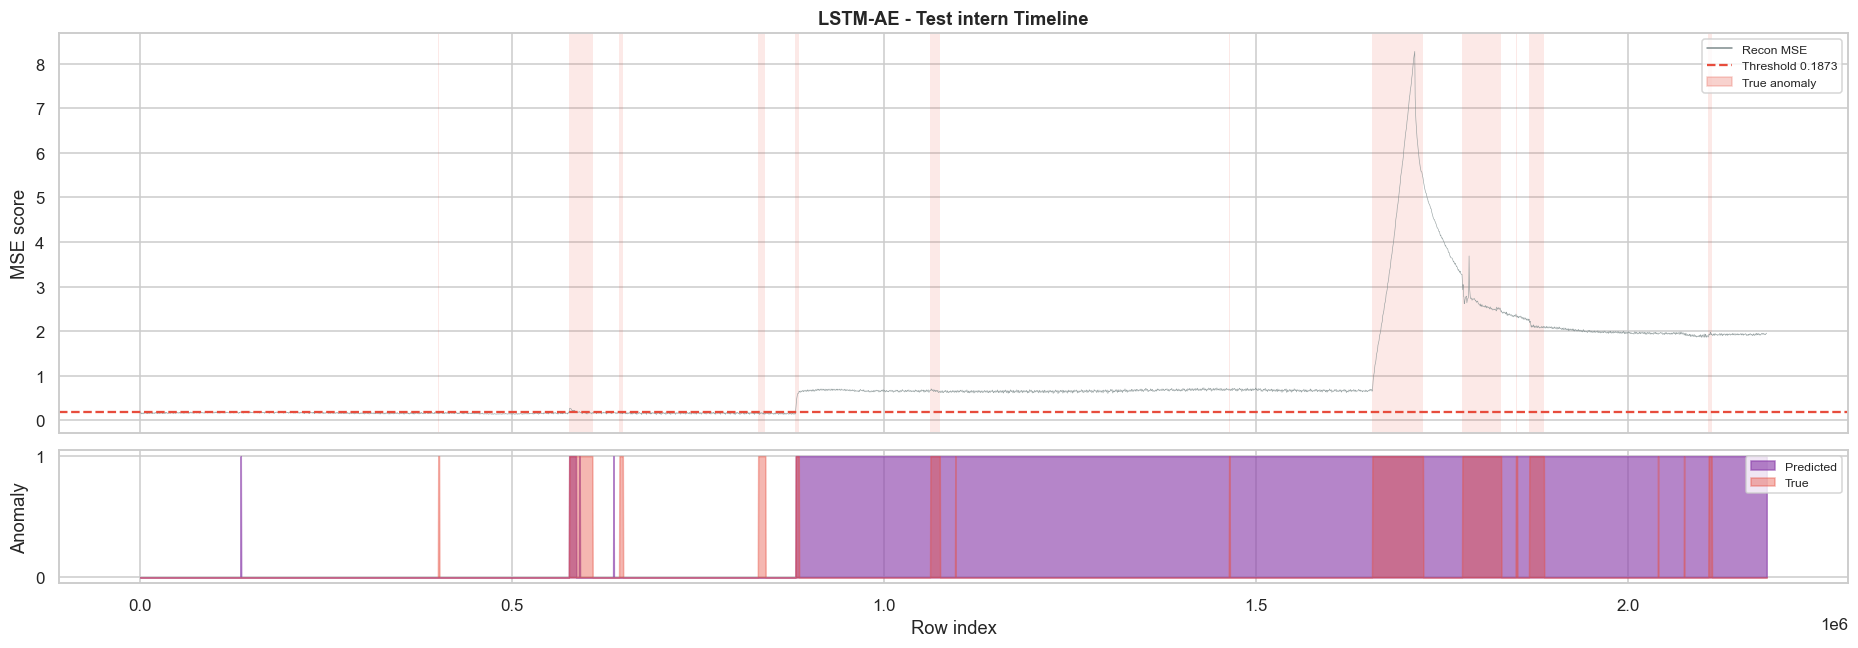

In [24]:
def plot_timeline(scores, y_true, threshold, title, ds=500):
    segments   = find_anomaly_segments(y_true)
    y_pred     = (scores > threshold).astype(np.int8)
    idx        = np.arange(0, len(scores), ds)
    scores_ds  = scores[idx]
    y_pred_ds  = y_pred[idx]
    y_true_ds  = y_true[idx]

    fig, axes = plt.subplots(2, 1, figsize=(17, 6), sharex=True,
                             gridspec_kw={'height_ratios': [3, 1]})
    ax = axes[0]
    ax.plot(idx, scores_ds, lw=0.4, color='#7f8c8d', alpha=0.8)
    ax.axhline(threshold, color=ANOMALY_COLOR, lw=1.5, ls='--',
               label=f'Threshold = {threshold:.4f}')
    for seg in segments:
        ax.axvspan(seg['start'], seg['end'], color=ANOMALY_COLOR, alpha=0.12, lw=0)
    ax.set_ylabel('MSE score')
    ax.set_title(title, fontweight='bold', fontsize=12)
    handles = [
        plt.Line2D([0],[0], color='#7f8c8d', lw=1, label='Recon MSE'),
        plt.Line2D([0],[0], color=ANOMALY_COLOR, lw=1.5, ls='--',
                   label=f'Threshold {threshold:.4f}'),
        mpatches.Patch(color=ANOMALY_COLOR, alpha=0.25, label='True anomaly'),
    ]
    ax.legend(handles=handles, fontsize=8, loc='upper right')

    ax2 = axes[1]
    ax2.fill_between(idx, y_pred_ds, color='#8e44ad', alpha=0.65, label='Predicted')
    ax2.fill_between(idx, y_true_ds.astype(float), color=ANOMALY_COLOR, alpha=0.4, label='True')
    ax2.set_yticks([0, 1]); ax2.set_ylabel('Anomaly')
    ax2.set_xlabel('Row index'); ax2.legend(fontsize=8, loc='upper right')

    fig.tight_layout(); plt.show()

plot_timeline(scores_val,         y_val,         THRESHOLD, f'{MODEL_NAME} - Val Timeline')
plot_timeline(scores_test_intern, y_test_intern, THRESHOLD, f'{MODEL_NAME} - Test intern Timeline')

---
## 8 - Per-Event Detection


In [25]:
def event_table(scores, y_true, threshold, label):
    segments = find_anomaly_segments(y_true)
    y_pred   = (scores > threshold).astype(np.int8)
    rows = []
    for seg in segments:
        n_det = int(y_pred[seg['start']:seg['end']+1].sum())
        rows.append({
            'start'      : seg['start'],
            'end'        : seg['end'],
            'length'     : seg['length'],
            'detected'   : n_det > 0,
            'hit_rate'   : round(n_det / seg['length'], 3),
        })
    df = pd.DataFrame(rows)
    n_det   = int(df['detected'].sum())
    n_miss  = len(df) - n_det
    print(f'{label}: {n_det}/{len(df)} events detected  ({n_miss} missed)')
    return df

df_val  = event_table(scores_val,         y_val,         THRESHOLD, f'{MODEL_NAME} Val')
df_test = event_table(scores_test_intern, y_test_intern, THRESHOLD, f'{MODEL_NAME} Test intern')

LSTM-AE Val: 13/26 events detected  (13 missed)
LSTM-AE Test intern: 25/27 events detected  (2 missed)


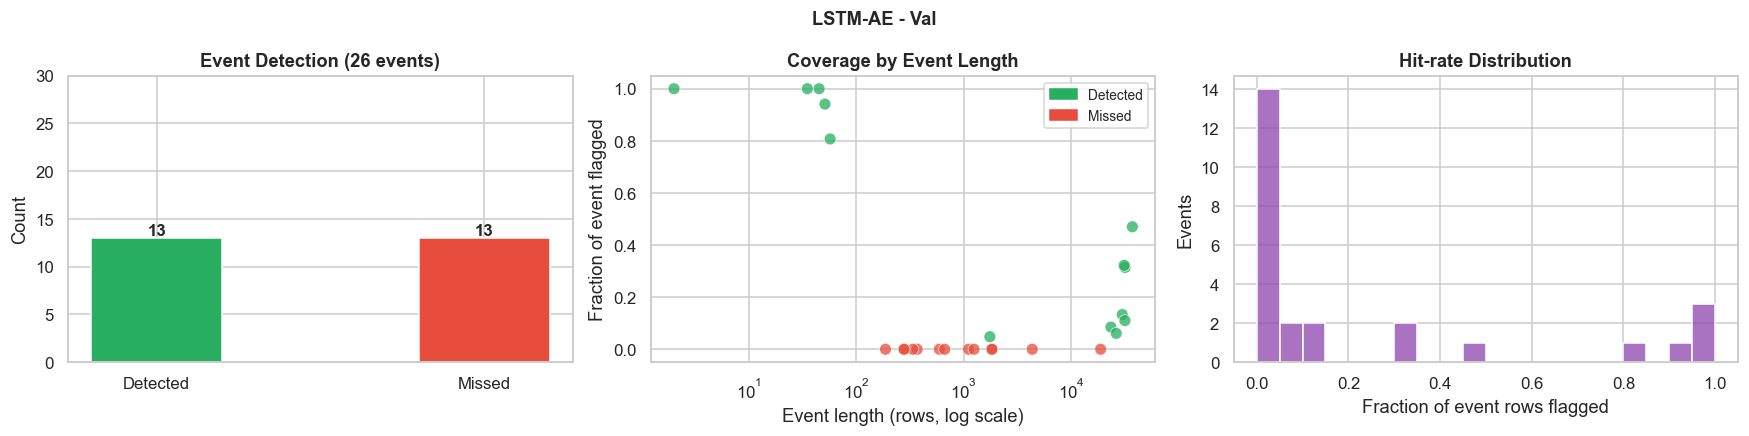

Missed events:
  start     end  length
  97133   97726     594
 399395  399763     369
 548497  552855    4359
 565099  584013   18915
 819541  819876     336
1337362 1339200    1839
1342475 1344310    1836
1556161 1556436     276
1912322 1912508     187
1912819 1913928    1110
1917562 1918227     666
2009869 2010147     279
2069274 2070523    1250


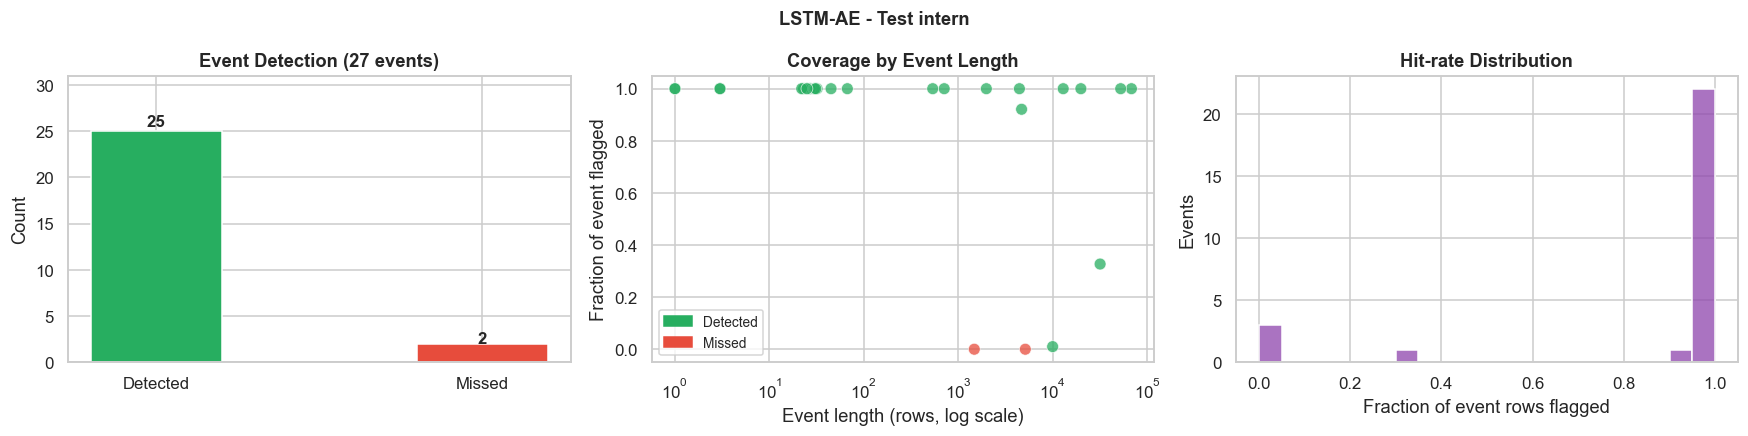

Missed events:
 start    end  length
400398 401877    1480
643518 648653    5136


In [26]:
def plot_event_analysis(df, scores, y_true, threshold, title):
    segments = find_anomaly_segments(y_true)
    y_pred   = (scores > threshold).astype(np.int8)
    n_det  = int(df['detected'].sum())
    n_miss = len(df) - n_det
    n_ev   = len(df)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Detected vs missed bar
    ax = axes[0]
    counts = pd.Series({'Detected': n_det, 'Missed': n_miss})
    colors = ['#27ae60', ANOMALY_COLOR]
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.4)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
                str(v), ha='center', fontsize=11, fontweight='bold')
    ax.set_title(f'Event Detection ({n_ev} events)', fontweight='bold')
    ax.set_ylabel('Count'); ax.set_ylim(0, n_ev + 4)

    # Hit rate by event length
    ax2 = axes[1]
    colors_pt = [('#27ae60' if d else ANOMALY_COLOR) for d in df['detected']]
    ax2.scatter(df['length'], df['hit_rate'], c=colors_pt, s=60, alpha=0.75,
                edgecolors='white', lw=0.5)
    ax2.set_xscale('log')
    ax2.set_xlabel('Event length (rows, log scale)')
    ax2.set_ylabel('Fraction of event flagged')
    ax2.set_title('Coverage by Event Length', fontweight='bold')
    ax2.set_ylim(-0.05, 1.05)
    handles = [mpatches.Patch(color='#27ae60', label='Detected'),
               mpatches.Patch(color=ANOMALY_COLOR, label='Missed')]
    ax2.legend(handles=handles, fontsize=9)

    # Hit-rate distribution
    ax3 = axes[2]
    sns.histplot(df['hit_rate'], bins=20, ax=ax3, color='#8e44ad', edgecolor='white')
    ax3.set_xlabel('Fraction of event rows flagged')
    ax3.set_ylabel('Events')
    ax3.set_title('Hit-rate Distribution', fontweight='bold')

    fig.suptitle(title, fontsize=12, fontweight='bold')
    fig.tight_layout(); plt.show()

    if n_miss:
        print('Missed events:')
        print(df[~df['detected']][['start','end','length']].to_string(index=False))

plot_event_analysis(df_val,  scores_val,         y_val,         THRESHOLD, f'{MODEL_NAME} - Val')
plot_event_analysis(df_test, scores_test_intern, y_test_intern, THRESHOLD, f'{MODEL_NAME} - Test intern')

---
## 9 - Bootstrap Confidence Interval
**TAKES VERY LONG**


In [27]:
y_pred_val  = (scores_val > THRESHOLD).astype(np.int8)
y_pred_test = (scores_test_intern > THRESHOLD).astype(np.int8)

print('Bootstrap CI (200 iterations, event-block) ...')
ci_val  = bootstrap_f05_ci(y_val,         y_pred_val,  n_boot=200)
ci_test = bootstrap_f05_ci(y_test_intern, y_pred_test, n_boot=200)

for label, ci in [('Val', ci_val), ('Test intern', ci_test)]:
    print(f'  {label:<12} F0.5 = {ci["mean"]:.4f} ± {ci["std"]:.4f}'
          f'  95% CI [{ci["ci_lo_95"]:.4f}, {ci["ci_hi_95"]:.4f}]')

Bootstrap CI (200 iterations, event-block) ...
  Val          F0.5 = 0.6590 ± 0.1107  95% CI [0.4542, 0.8475]
  Test intern  F0.5 = 0.6083 ± 0.0558  95% CI [0.5118, 0.7088]


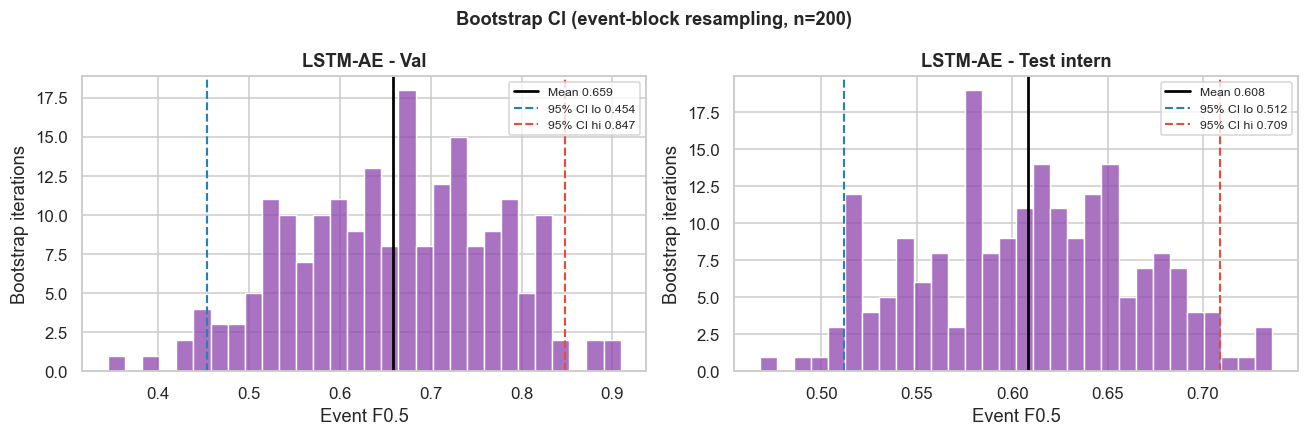

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (label, ci) in zip(axes, [('Val', ci_val), ('Test intern', ci_test)]):
    sns.histplot(ci['all_scores'], bins=30, ax=ax, color='#8e44ad', edgecolor='white')
    ax.axvline(ci['mean'],    color='black',        lw=1.8, ls='-',  label=f'Mean {ci["mean"]:.3f}')
    ax.axvline(ci['ci_lo_95'], color=NOMINAL_COLOR, lw=1.4, ls='--', label=f'95% CI lo {ci["ci_lo_95"]:.3f}')
    ax.axvline(ci['ci_hi_95'], color=ANOMALY_COLOR, lw=1.4, ls='--', label=f'95% CI hi {ci["ci_hi_95"]:.3f}')
    ax.set_xlabel('Event F0.5')
    ax.set_ylabel('Bootstrap iterations')
    ax.set_title(f'{MODEL_NAME} - {label}', fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Bootstrap CI (event-block resampling, n=200)', fontsize=12, fontweight='bold')
fig.tight_layout(); plt.show()